# ADS Downloader

## Initialize

In [1]:
import ads
from bs4 import BeautifulSoup
from google import genai
import numpy as np
import openai
import os
import pandas as pd
import pdb
import pdfplumber
import requests
import tiktoken

# Configure tokens for select APIs
ads_token = 'insert api token'
ads.config.token = ads_token
goog_token = 'insert api token'
client = genai.Client(api_key = goog_token)

# Set AI model
# For details on the capabilities of each Gemini variant, see https://ai.google.dev/gemini-api/docs/models
# For details on the rate limits of each Gemini variant, see https://ai.google.dev/gemini-api/docs/rate-limits
AI_Model = "gemini-2.0-flash"

In [25]:
def scrape_table(url, table_index=0):
    """
    Finds tables from webpage using given url and scrapes their contents into a DataFrame
    ---
    Parameters
    url: (str) Link to webpage of interest containing at least one table
    (opt) table_index: (int) Selects which table to parse if page contains more than one, defaults to 0 (first one)
    ---
    Returns
    df: (Data Frame) Webpage table contents
    ---
    Note 
    Generated using OpenAI ChatGPT
    """
    
    # Send a GET request to the webpage
    response = requests.get(url)
    response.raise_for_status()  # Raise an error for failed requests
    
    # Parse the webpage content
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # Find all tables on the webpage
    tables = soup.find_all('table')
    
    if not tables:
        print("No tables found on the webpage.")
        return None

    # Select the desired table (default is the first one)
    table = tables[table_index]
    
    # Extract table headers
    headers = [header.text.strip() for header in table.find_all('th')]
    
    # Extract table rows
    rows = []
    for row in table.find_all('tr')[1:]:  # Skip header row
        cells = row.find_all('td')
        row_data = [cell.text.strip() for cell in cells]
        rows.append(row_data)
    
    # Create a DataFrame
    df = pd.DataFrame(rows, columns=headers if headers else None)
    
    return df


def get_disk_lit(disk_name_orig, save_dir = "Scraped_Table_Data"):
    """
    Retrieves scored literature information from SIMBAD for a given disk and saves it as a .csv to desired folder
    ---
    Parameters
    disk_name_orig: (str) Plain text name of disk of interest. Any name recognized by SIMBAD should work 
                    (i.e. "2MASS J16004452-4155310" should return the same result as "MY Lup")
    (opt) save_dir: (str) Name of folder to which the .csv will be saved, defaults to "Scraped_Table_Data"
    ---
    Note
    Created in part using OpenAI ChatGPT
    """

    # Create versions of disk name for web-searchability and file saving
    disk_name=disk_name_orig.replace(" ", "%20")
    disk_name_file = disk_name_orig.replace(" ", "_")

    # Dynamically construct the SIMBAD URL without a hardcoded identifier
    baseurl = 'https://simbad.cds.unistra.fr/simbad/sim-id-refs?Ident='
    url = baseurl+disk_name

    # Scrape SIMBAD
    df = scrape_table(url,table_index=2)

    if df is not None:
        filtered_df = df[df['Score'] != '']
        filtered_df['Score'] = filtered_df['Score'].astype(int) # so not treated as strings
        df_sorted = filtered_df.sort_values(by='Score',ascending=False)
        print(df_sorted)
        os.makedirs(save_dir, exist_ok=True)
        df_sorted.to_csv(save_dir+"/%s_scraped_table.csv"%(disk_name_file), index=False)  # Save to CSV


def select_papers(disk_name_orig, score_limit = 0, paper_limit = 5):
    '''
    Insert docstring notes
    '''
    
    # Create version of disk name for file reading
    disk_name_file = disk_name_orig.replace(" ", "_")

    home_path = os.getcwd() + "\\"

    bibcodes = []

    # Read .csv
    df_Literature = pd.read_csv(home_path + "Scraped_Table_Data/" + disk_name_file + r"_scraped_table.csv", index_col=False)
    
    for i in range(paper_limit):
        if df_Literature['Score'][i] > score_limit:
            bibcode = df_Literature['Bibcode/DOI'][i]
            bibcodes.append(bibcode)

    # Notify user if parameters cause constraints
    if len(bibcodes) == 0:
        print('No literature exists for', disk_name_orig, 'within given parameters. Consider adjusting your score limit.')
    elif len(bibcodes) == 1:
        print('Only', len(bibcodes), 'bibcode for', disk_name_orig, 'found with SIMBAD score over', score_limit)
    elif len(bibcodes) < paper_limit:
        print('Only', len(bibcodes), 'bibcodes for', disk_name_orig, 'found with SIMBAD scores over', score_limit)
    else: 
        print(len(bibcodes), 'bibcodes found for', disk_name_orig)

    return bibcodes


def download_pdfs(bibcodes, save_dir):
    """
    Insert docstring notes
    """
    
    for bibcode in bibcodes:
        # Query ADS for the article's PDF link
        print(f"Checking bibcode: {bibcode}")
        papers = list(ads.SearchQuery(bibcode=bibcode, fl=["bibcode", "title", "esources"]))
        
        if not papers:
            print(f"No results found for {bibcode}")
            continue
        
        paper = papers[0]
        
        # Check if a PDF link is available
        if "EPRINT_PDF" in paper.esources:
            pdf_url = f"https://ui.adsabs.harvard.edu/link_gateway/{bibcode}/EPRINT_PDF"
        elif "PUB_PDF" in paper.esources:
            pdf_url = f"https://ui.adsabs.harvard.edu/link_gateway/{bibcode}/PUB_PDF"
        else:
            print(f"No PDF available for {bibcode}")
            continue

        print(f"Downloading {bibcode} from {pdf_url}")

        # Retrieve and save the PDF
        response = requests.get(pdf_url, allow_redirects=True)
        if response.status_code == 200:
            filename = os.path.join(save_dir, f"{bibcode}.pdf")
            with open(filename, "wb") as f:
                f.write(response.content)
            print(f"Saved {filename}")
        else:
            print(f"Failed to download {bibcode}, status code: {response.status_code}")

    
def extract_text_from_pdf(pdf_path: str) -> str:
    '''
    Extracts text from pdf
    ---
    Parameters
    pdf_path: (str) Path to pdf from which to extract text
    ---
    Returns
    text_str: (str) Text from pdf as one long string
    ---
    Note: Generated using OpenAI ChatGPT
    '''
    text_pages = []
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text() or ""
            text_pages.append(page_text)
    text_str = "\n\n".join(text_pages)
    return text_str


def chunk_text(text: str,
               max_tokens: int = 1500,
               model: str = "gpt-4") -> list[str]:
    '''
    Breaks pdf text into token limited chunks
    ---
    Parameters
    text:
    max_tokens: 
    model: 
    ---
    Returns
    chunks: 
    ---
    Note: Generated using OpenAI ChatGPT
    '''
    encoder = tiktoken.encoding_for_model(model)
    tokens = encoder.encode(text)
    
    chunks = []
    for i in range(0, len(tokens), max_tokens):
        chunk_chunk = tokens[i : i + max_tokens]
        chunks.append(encoder.decode(chunk_chunk))
    return chunks

## Collect Literature

In [3]:
# Pathing

home_path = os.getcwd() + "\\"
df_Source_Names = pd.read_csv(home_path + r"Source_Names.csv", index_col=False)

In [4]:
df_Source_Names

,Region,Source,Simbad Id
0,ChaI,J11113965-7620152,V* XX Cha
1,ChaI,J11105333-7634319,V* WZ Cha
2,ChaI,J11104959-7717517,Ass Cha T 1-27
3,ChaI,J11092379-7623207,V* VZ Cha
4,ChaI,J11085367-7521359,V* PU Car
...,...,...,...
75,Taurus,LkCa 15,EM* LkCa 15
76,Taurus,DG Tau,V* DG Tau
77,Taurus,HP Tau,V* HP Tau
78,Taurus,CW Tau,V* CW Tau


In [5]:
#df_Source_Names["Region"]

print(df_Source_Names["Region"])

0       ChaI
1       ChaI
2       ChaI
3       ChaI
4       ChaI
       ...  
75    Taurus
76    Taurus
77    Taurus
78    Taurus
79    Taurus
Name: Region, Length: 80, dtype: object


In [6]:
row_hptau = df_Source_Names.loc[df_Source_Names['Source'] == 'HP Tau']
print(row_hptau["Region"].values)

['Taurus']


In [7]:
tau_rows = df_Source_Names.loc[df_Source_Names['Region'] == 'Taurus']
print(tau_rows['Source'])

60      FN Tau
61      HO Tau
62      DM Tau
63      FT Tau
64      DE Tau
65      IQ Tau
66    V836 Tau
67      DS Tau
68      GI Tau
69      IP Tau
70      GK Tau
71      DR Tau
72      CI Tau
73      DL Tau
74      GM Aur
75     LkCa 15
76      DG Tau
77      HP Tau
78      CW Tau
79      HQ Tau
Name: Source, dtype: object


In [8]:
# Get literature data from each disk name

for source in tau_rows['Source']:
    #source_file = source.replace(' ','_')
    get_disk_lit(source)

#name = 'MY Lup'
#name_file = name.replace(' ','_')

#get_disk_lit(name)

C:\Users\m42ha\AppData\Local\Temp\ipykernel_12128\1352173975.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Score'] = filtered_df['Score'].astype(int) # so not treated as strings


             Bibcode/DOI  Score in Title|Abstract|Keywords in a table  \
70   2008ApJ...673L..67K   1947                      T K A          D   
86   2010ApJ...712..397M   1349                      T K A              
166  2023AJ....166...82L    914                                     D   
102  2013ApJ...769...73M    752                                     D   
76   2009ApJS..182..477S    618                                     D   
..                   ...    ...                        ...        ...   
40   1997A&AS..126..437H      1                                         
59   2003ApJ...592..266M      1                                         
29   1993AJ....106.2005G      1                                         
18   1989AJ.....97.1451S      1                                         
5    1976ApJS...30..307R      1                                         

    in teXt, Caption, ... Nb occurence Nb objects in ref Citations(from ADS)  \
70                S   X C           50     

C:\Users\m42ha\AppData\Local\Temp\ipykernel_12128\1352173975.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Score'] = filtered_df['Score'].astype(int) # so not treated as strings


             Bibcode/DOI  Score in Title|Abstract|Keywords in a table  \
85   2014A&A...564A..95P    484                                     D   
95   2017ApJ...844..158S    418                                     D   
135  2024PASJ...76..437Y    392                                     D   
137  2025A&A...694A.290G    370                                     D   
66   2010A&A...512A..15R    321                                     D   
..                   ...    ...                        ...        ...   
25   1994ApJ...427..961H      1                                         
37   2001ApJ...556..265W      1                                         
26   1994ARA&A..32..465M      1                                         
46   2005ApJ...631.1134A      1                                         
14   1989AJ.....97.1451S      1                                         

    in teXt, Caption, ... Nb occurence Nb objects in ref Citations(from ADS)  \
85                    O X           13     

C:\Users\m42ha\AppData\Local\Temp\ipykernel_12128\1352173975.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Score'] = filtered_df['Score'].astype(int) # so not treated as strings


...

C:\Users\m42ha\AppData\Local\Temp\ipykernel_12128\1352173975.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Score'] = filtered_df['Score'].astype(int) # so not treated as strings


             Bibcode/DOI  Score in Title|Abstract|Keywords in a table  \
203  2021A&A...651A..44R    996                                     D   
228  2025AJ....169..165B    820                                     D   
231  2025A&A...694A.290G    820                                     D   
226  2024ApJ...975...78R    812                                     D   
140  2009ApJ...698..242T    742                          A              
..                   ...    ...                        ...        ...   
70   1994ApJ...427..961H      1                                         
118  2005ApJ...631.1134A      1                                         
114  2004ApJ...616..998W      1                                         
101  2000A&A...355..165D      1                                         
32   1989AJ.....97..483V      1                                         

    in teXt, Caption, ... Nb occurence Nb objects in ref Citations(from ADS)  \
203               S   X C           22     

C:\Users\m42ha\AppData\Local\Temp\ipykernel_12128\1352173975.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Score'] = filtered_df['Score'].astype(int) # so not treated as strings


             Bibcode/DOI  Score in Title|Abstract|Keywords in a table  \
172  2007A&A...467.1197M   2756                          A          D   
344  2022ApJ...930...56U   1899                      T   A              
358  2023A&A...675A.176U   1057                          A              
304  2018ApJ...865L..12B   1008                      T   A              
290  2016ApJ...831..169S    851                                     D   
..                   ...    ...                        ...        ...   
78   1994AJ....108.1906H      1                                         
132  2001ApJ...551.1037B      1                                         
128  2001A&A...367..959R      1                                         
133  2001ApJ...556..265W      1                                         
263  2013AstL...39..389D      1                                         

    in teXt, Caption, ... Nb occurence Nb objects in ref Citations(from ADS)  \
172               S   X C           73     

C:\Users\m42ha\AppData\Local\Temp\ipykernel_12128\1352173975.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Score'] = filtered_df['Score'].astype(int) # so not treated as strings


In [29]:
# Select papers from saved literature data and download their pdfs to respective source folders

for name in tau_rows['Source']:
    name_file = name.replace(' ','_')
    
    # Directory to save PDFs
    save_dir = "ADS_Papers/Taurus_Papers/" + name_file
    os.makedirs(save_dir, exist_ok=True)
    
    # Run the functions
    download_pdfs(select_papers(name), save_dir)

5 bibcodes found for FN Tau
Checking bibcode: 2008ApJ...673L..67K
Saved ADS_Papers/Taurus_Papers/FN_Tau\2008ApJ...673L..67K.pdf
Checking bibcode: 2010ApJ...712..397M
Saved ADS_Papers/Taurus_Papers/FN_Tau\2010ApJ...712..397M.pdf
Checking bibcode: 2023AJ....166...82L
Saved ADS_Papers/Taurus_Papers/FN_Tau\2023AJ....166...82L.pdf
Checking bibcode: 2013ApJ...769...73M
Saved ADS_Papers/Taurus_Papers/FN_Tau\2013ApJ...769...73M.pdf
Checking bibcode: 2009ApJS..182..477S
Saved ADS_Papers/Taurus_Papers/FN_Tau\2009ApJS..182..477S.pdf
5 bibcodes found for HO Tau
Checking bibcode: 2014A&A...564A..95P
Saved ADS_Papers/Taurus_Papers/HO_Tau\2014A&A...564A..95P.pdf
Checking bibcode: 2017ApJ...844..158S
Saved ADS_Papers/Taurus_Papers/HO_Tau\2017ApJ...844..158S.pdf
Checking bibcode: 2024PASJ...76..437Y
Saved ADS_Papers/Taurus_Papers/HO_Tau\2024PASJ...76..437Y.pdf
Checking bibcode: 2025A&A...694A.290G
Saved ADS_Papers/Taurus_Papers/HO_Tau\2025A&A...694A.290G.pdf
Checking bibcode: 2010A&A...512A..15R
Saved 

## PDF Reading

In [31]:
file_path = home_path + "ADS_Papers\\MY_LUP\\2022ApJ...932..114L.pdf"

file_text = extract_text_from_pdf(file_path)

CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, def

CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, def

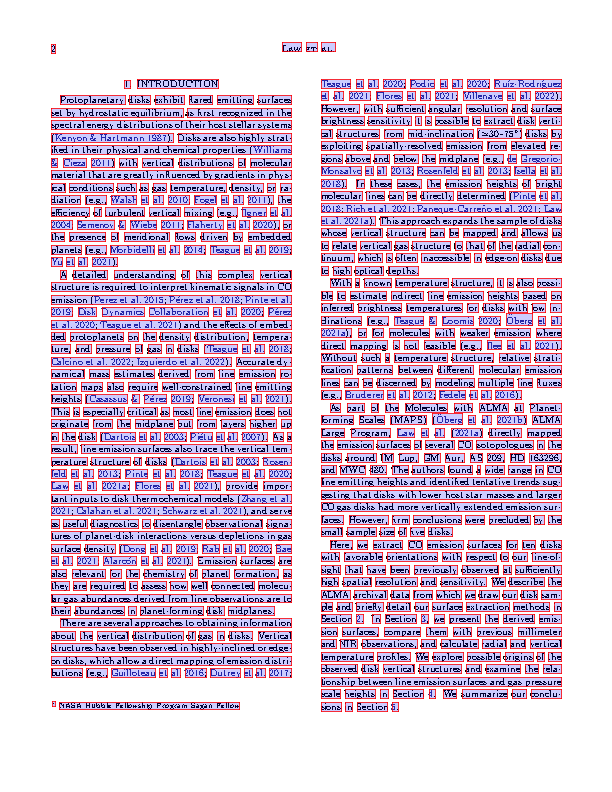

In [37]:
pdf = pdfplumber.open(file_path)#, repair=True)
page = pdf.pages[1]
im = page.to_image()
im.draw_rects(page.extract_words())
im.save("pdfplumber-bad-cropbox.jpg")
im

In [35]:
print(file_text)

TypesetusingLATEXtwocolumnstyleinAASTeX631
Draft version May 5, 2022
CO Line Emission Surfaces and Vertical Structure in Mid-Inclination Protoplanetary Disks
Charles J. Law ,1 Sage Crystian ,1 Richard Teague ,1 Karin I. O¨berg ,1 Evan A. Rich ,2
Sean M. Andrews ,1 Jaehan Bae ,3 Kevin Flaherty ,4 Viviana V. Guzma´n ,5 Jane Huang ,2,∗
John D. Ilee ,6 Joel H. Kastner ,7 Ryan A. Loomis ,8 Feng Long ,1 Laura M. Pe´rez ,9,10
Sebastia´n Pe´rez ,11,12 Chunhua Qi ,1 Giovanni P. Rosotti ,13 Dary Ru´ız-Rodr´ıguez ,8
Takashi Tsukagoshi ,14 and David J. Wilner 1
1Center for Astrophysics | Harvard & Smithsonian, 60 Garden St., Cambridge, MA 02138, USA
2Department of Astronomy, University of Michigan, 323 West Hall, 1085 South University Avenue, Ann Arbor, MI 48109, USA
3Department of Astronomy, University of Florida, Gainesville, FL 32611, USA
4Department of Astronomy and Department of Physics, Williams College, Williamstown, MA 01267, USA
5Instituto de Astrof´ısica, Pontificia Universidad Cat´olica

## Gemini Integration

In [13]:
response = client.models.generate_content(
    model=AI_Model, contents="Explain how AI works in a few words"
)
print(response.text)

AI learns from data to make predictions or decisions.



In [18]:
# Updated prompt texts
prompt_summarize_article = (
    "Please critically read the attached academic paper and write a 2-5 paragraph summary. "
    "Focus on the major conclusions and any innovative scientific processes detailed in the paper. "
    "If there are interesting human elements or contextual details relevant to a wiki entry, please note them as well."
)

prompt_write_entry = (
    "Please read and fully understand these 5 summaries about the same protoplanetary disk. "
    "Then write a cohesive wiki entry that covers all the relevant information without unnecessary repetition. "
    "Begin with the most important information and conclusions. If there are any fun or interesting elements, highlight them appropriately."
)

In [19]:
response = client.models.generate_content(
    model=AI_Model, contents=prompt_summarize_article
)
print(response.text)

Please provide me with the academic paper you want me to review. I need the text of the paper to provide you with a critical summary and identify any innovative scientific processes, human elements, or contextual details relevant to a wiki entry. Once you provide the paper, I will be happy to assist you.



In [20]:
model_info = client.models.get(model=AI_Model)
print(f"{model_info.input_token_limit=}")
print(f"{model_info.output_token_limit=}")

model_info.input_token_limit=1048576
model_info.output_token_limit=8192


### Token Count

In [40]:
# Count tokens using the new client method.
total_tokens = client.models.count_tokens(
    model="gemini-2.0-flash", contents=file_text
)
print("total_tokens: ", total_tokens)
# ( e.g., total_tokens: 10 )

total_tokens:  total_tokens=38954 cached_content_token_count=None


In [ ]:
# Assume we have 80 disks each with 5 associated paper texts
num_disks = 2
num_papers_per_disk = 5

# For demonstration, create dummy paper texts
dummy_paper_texts = [
    f"Full text of academic paper {i+1}" for i in range(num_papers_per_disk)
]

# Create an empty DataFrame to store the summaries
summaries = pd.DataFrame(
    data=np.empty((num_disks, num_papers_per_disk), dtype=object),
    columns=[f"Paper_{i+1}_Summary" for i in range(num_papers_per_disk)]
)
 
# Loop over each disk and each paper
for disk_idx in range(num_disks):
    for paper_idx in range(num_papers_per_disk):
        # In reality, replace dummy_paper_texts[paper_idx] with the actual content
        paper_text = dummy_paper_texts[paper_idx]
        # Call Gemini API to get the summary for the current paper
        summary = gemini_api_call(prompt_summarize_article, paper_text)
        # Store the summary in the DataFrame
        summaries.iloc[disk_idx, paper_idx] = summary

# Show a preview of the summaries DataFrame
summaries.head()
